In [13]:
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
matplotlib.rcParams['font.size'] = 10
matplotlib.rcParams['figure.figsize'] = (10, 6)


In [14]:
# 定义文件路径
base_path = Path('.')
files = {
    'wikitext_thinking_on': 'wikitext_thinking_on.json',
    'humaneval_thinking_on': 'humaneval_thinking_on.json',
    'gsm8k_thinking_off': 'gsm8k_thinking_off.json'
}

# 定义要可视化的层
layers = [1, 47]

# 加载数据
data = {}
for name, filename in files.items():
    with open(filename, 'r') as f:
        data[name] = json.load(f)
    print(f"Loaded {name}: {len(data[name])} layers")


Loaded wikitext_thinking_on: 48 layers
Loaded humaneval_thinking_on: 48 layers
Loaded gsm8k_thinking_off: 48 layers


In [30]:
def extract_layer_data(layer_data):
    """从层数据中提取expert ID和激活次数"""
    experts = []
    activations = []
    for expert_id, count in layer_data.items():
        experts.append(int(expert_id))
        activations.append(round(float(count)/1000, 2))
    # 按expert ID排序
    sorted_pairs = sorted(zip(experts, activations))
    experts, activations = zip(*sorted_pairs)
    return list(experts), list(activations)


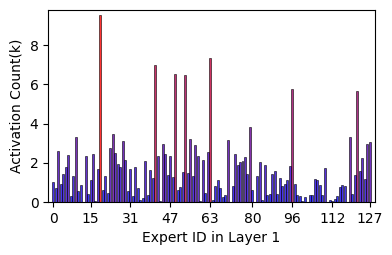

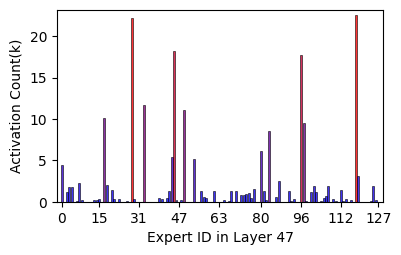

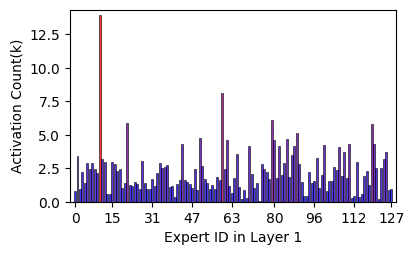

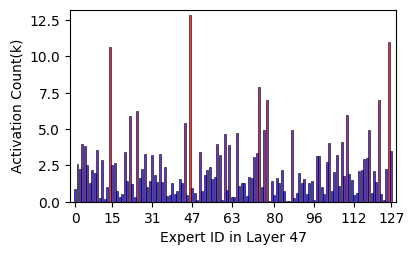

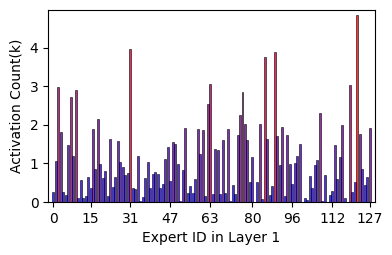

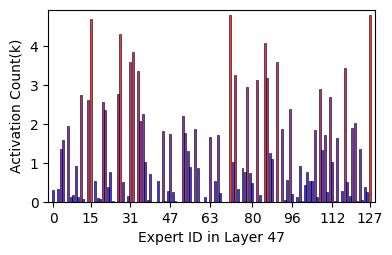

In [36]:
# 创建从蓝色到红色的渐变色映射
colors = ['#0000FF', '#FF0000']  # 蓝色到红色
n_bins = 100
cmap = LinearSegmentedColormap.from_list('blue_red', colors, N=n_bins)

# 为每个数据集和每层单独创建柱状图
for dataset_name in data.keys():
    for layer_num in layers:
        if layer_num < len(data[dataset_name]):
            layer_data = data[dataset_name][layer_num]
            experts, activations = extract_layer_data(layer_data)
            
            # 创建单独的figure
            fig, ax = plt.subplots(figsize=(6.4*0.6, 4.8*0.5))
            
            # 归一化激活值用于颜色映射（0=蓝色，1=红色）
            if max(activations) > 0:
                normalized = [val / max(activations) for val in activations]
            else:
                normalized = [0] * len(activations)
            
            # 为每个柱子创建渐变色
            bars = []
            for i, (expert, activation) in enumerate(zip(experts, activations)):
                # 根据激活值获取颜色（值越大越红，值越小越蓝）
                color = cmap(normalized[i])
                bar = ax.bar(expert, activation, color=color, alpha=0.8, 
                            edgecolor='black', linewidth=0.5, width=0.8)
                bars.append(bar)
            
            ax.set_xlabel(f'Expert ID in Layer {layer_num}', fontsize=10)
            ax.set_ylabel('Activation Count(k)', fontsize=10)
            
            # 设置x轴刻度：固定为指定的9个刻度
            fixed_ticks = [0, 15, 31, 47, 63, 80, 96, 112, 127]
            ax.set_xticks(fixed_ticks)
            
            # 减少留白：设置x轴和y轴的范围
            if len(experts) > 0:
                # x轴：从第一个expert稍微左移，到最后一个expert稍微右移
                x_min = min(experts) - 2
                x_max = max(experts) + 2
                ax.set_xlim(x_min, x_max)
            
            # y轴：从0开始，到最大值稍微高一点（留3%的空间）
            if len(activations) > 0 and max(activations) > 0:
                y_max = max(activations) * 1.03
                ax.set_ylim(0, y_max)
            
            # 减少整体留白
            plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.15)
            plt.savefig(f'{dataset_name}_layer_{layer_num}.pdf', format='pdf', 
                       bbox_inches='tight', pad_inches=0.05)
            plt.show()
        else:
            print(f"Layer {layer_num} not available for {dataset_name}")
